In [9]:
import scqubits
import numpy as np

In [10]:
EJ = 4
EC = 1
EL = 4/20
qubit_level=20
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)


In [11]:
data = qbt.get_spectrum_vs_paramvals('EL',param_vals=np.linspace(4/100,4/13,100),evals_count=20,subtract_ground=True)

Spectral data:   0%|          | 0/100 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$E_L$', ylabel='energy [GHz]'>)

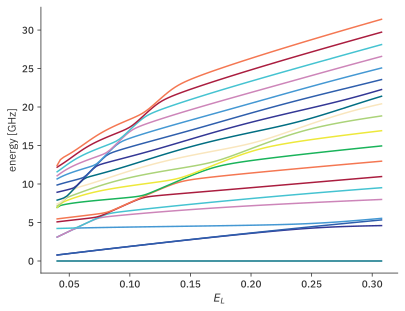

In [12]:
data.plot_evals_vs_paramvals()

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

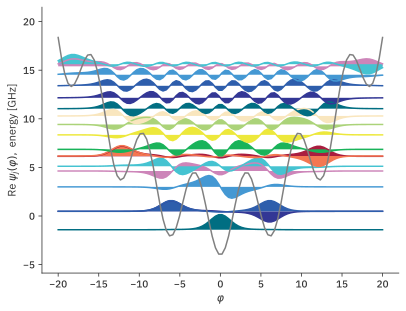

In [16]:
from scqubits.core.discretization import Grid1d
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=0.1,flux=0,cutoff=110,truncated_dim=qubit_level)
qbt.plot_wavefunction(which=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17],phi_grid=Grid1d(-20,20,100))

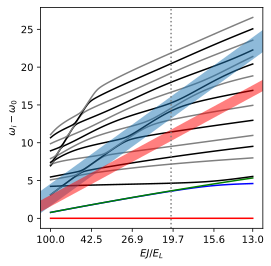

In [83]:
# EJ_over_EL_list = np.linspace(1/100,1/13,100)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4,4))
for i in range(17):
    if i == 0:
        color = 'red'
    elif i == 1:
        color = 'blue'
    elif i == 2:
        color = 'green'
    # elif i in [13,14,15]:
    #     color = 'yellow'
    elif i % 2 == 1:
        color = 'black'
    else:
        color = 'grey'
    plt.plot(data.param_vals,data.energy_table[:,i],color=color)

x1 = data.param_vals[0]
y1 = 3.1064760086667267
x2 = data.param_vals[40]
y2 = 10.93712112468258
plt.axline((x1,y1 ), (x2, y2),alpha = 0.5,linewidth = 18)

plt.axline((x1,y1 - data.energy_table[0,1] ), (x2, y2 - data.energy_table[40,1] ),alpha = 0.5,linewidth = 10,color = 'red')

plt.axline((data.param_vals[59],0),(data.param_vals[59],10),color='grey',linestyle = ':')

plt.ylabel(r'$\omega_i-\omega_0$')

plt.xlabel(r'$EJ/E_L$')
ticks = np.array([data.param_vals[0],data.param_vals[20],data.param_vals[40],data.param_vals[60],data.param_vals[80],data.param_vals[-1]])
tick_labels = 4/ticks
tick_labels = np.trunc(tick_labels * 10) / 10

plt.xticks(ticks,tick_labels )
plt.savefig('sweep_EL.pdf')

In [84]:
data.param_vals[30]

0.12111888111888114

In [19]:
zero_five =  data.energy_table[:,5]-data.energy_table[:,0]
zero_seven =  data.energy_table[:,7]-data.energy_table[:,0]
zero_nine =  data.energy_table[:,9]-data.energy_table[:,0]

one_ten =  data.energy_table[:,10]-data.energy_table[:,1]
two_eleven =  data.energy_table[:,11]-data.energy_table[:,2]

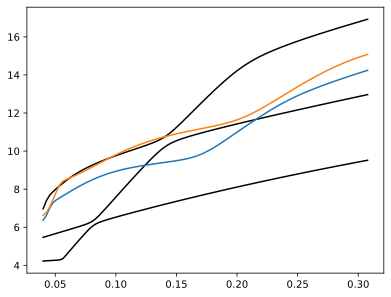

In [20]:
plt.plot(data.param_vals,zero_five,color='black')
plt.plot(data.param_vals,zero_seven,color='black')
plt.plot(data.param_vals,zero_nine,color='black')

plt.plot(data.param_vals,one_ten)
plt.plot(data.param_vals,two_eleven)

In [1]:

import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *

colors = [(0.7, 0.6, 0.0), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

def plot_fluxonium_transitions(ax,matrix, energies,xlim,qls = [0,1,2],ylim = (2e-3,0.8) ):
    from random import random 
        
    k = len(energies)  # Assuming matrix is k x k and energies is a list of length k
                        
    label_positions = []

    def check_collision_and_direction(new_pos, existing_positions, x_threshold=1.5, y_threshold=0.1):
        for pos in existing_positions:
            dx = new_pos[0] - pos[0]
            dy = np.log10(new_pos[1]) - np.log10(pos[1])
            if abs(dx)<0.5:
                if dy < y_threshold and dy >= 0:
                    print('detected')
                    return 1
                elif dy > -1* y_threshold and dy <= 0:
                    print('detected')
                    return -1
                    
        return False


    for i in qls:
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 3e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o', color='grey', markersize=4)

                if element_ij >= 3e-3:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    text_pos = (x_loc, y_loc)


                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        ax.text(*(x_loc,y_loc), rf'{i}-{j}', size=9)
                        label_positions.append(text_pos)
                    else:
                        # print(f'omitted: {i}-{j}')
                        pass

    # ax.set_xlabel(r'transition frequency $\omega_{ij}$')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.set_xlim(xlim)
    # ax.set_yscale('log')
    ax.set_ylim(ylim)


def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):

    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$')


(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

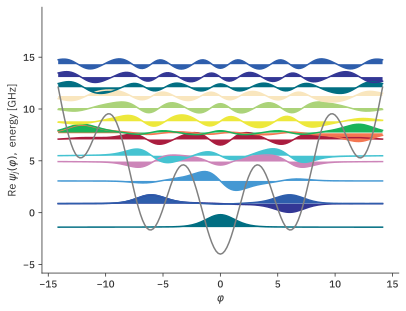

In [92]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 0.12111888111888114, cutoff = 110,flux = 0,truncated_dim=20)
qbt.plot_wavefunction(which=list(range(15)))

Er loop: 100%|██████████| 1000/1000 [00:00<00:00, 49796.44it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_44070/3081486241.py: 9

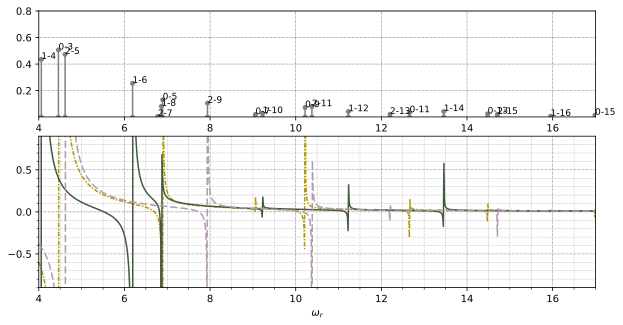

In [91]:

eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(4,17,int(1e3))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.9,0.9))
plt.tight_layout()
plt.show()

In [101]:
EJ = 4
EC = 1
EL = 4/20
qubit_level=20
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
data = qbt.get_spectrum_vs_paramvals('EJ',param_vals=np.linspace(2,10,100),evals_count=20,subtract_ground=True)

Spectral data:   0%|          | 0/100 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$E_J$', ylabel='energy [GHz]'>)

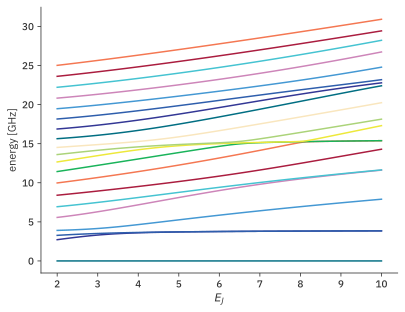

In [102]:
data.plot_evals_vs_paramvals()

Text(0.5, 0, 'EJ/EC with EC/EL = 5')

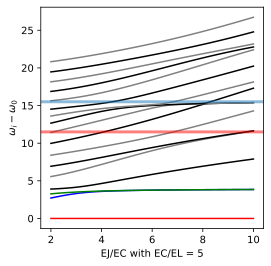

In [143]:
# EJ_over_EL_list = np.linspace(1/100,1/13,100)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4,4))
for i in range(17):
    if i == 0:
        color = 'red'
    elif i == 1:
        color = 'blue'
    elif i == 2:
        color = 'green'
    # elif i in [9,10,11,12]:
    #     color = 'orange'
    elif i % 2 == 1:
        color = 'black'
    else:
        color = 'grey'
    plt.plot(data.param_vals,data.energy_table[:,i],color=color)

plt.ylabel(r'$\omega_i-\omega_0$')

er = 11.5

plt.axline((2,er+4 ), (10, er+4),alpha = 0.5,linewidth = 3)

plt.axline((2,er ), (10, er),alpha = 0.5,linewidth = 3,color='red')
plt.xlabel('EJ/EC with EC/EL = 5')

# plt.savefig('sweep_EJ.pdf')

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

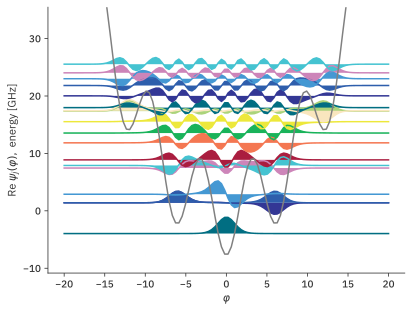

In [157]:
from scqubits.core.discretization import Grid1d
qbt = scqubits.Fluxonium(EJ=7.7,EC=4/4,EL=4/14,flux=0,cutoff=110,truncated_dim=qubit_level)
qbt.plot_wavefunction(which=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17],phi_grid=Grid1d(-20,20,100))

Er loop: 100%|██████████| 1000/1000 [00:00<00:00, 41510.91it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_44070/194927067.py: 9

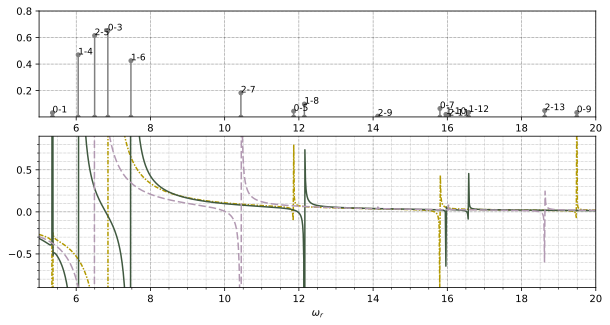

In [158]:

eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(5,20,int(1e3))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.9,0.9))
plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 1000/1000 [00:00<00:00, 30320.34it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_44070/2613173648.py: 9

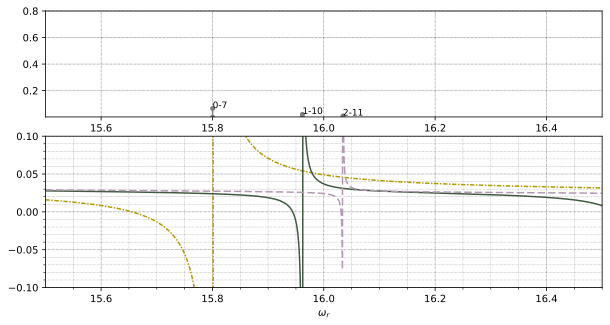

In [159]:

eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(15.5,16.5,int(1e3))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))
plt.tight_layout()
plt.show()


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.0019733307170273218
qbt freq at osc 1:	0.00203, 	diff to at osc ground 0.00005, 2.7562% diff
qbt freq at osc 2:	0.00208, 	diff to at osc ground 0.00011, 5.5236% diff
qbt freq at osc 3:	0.00214, 	diff to at osc ground 0.00016, 8.3021% diff
qbt freq at osc 4:	0.00219, 	diff to at osc ground 0.00022, 11.0919% diff
qbt freq at osc 5:	0.00225, 	diff to at osc ground 0.00027, 13.8929% diff
qbt freq at osc 6:	0.00230, 	diff to at osc ground 0.00033, 16.7053% diff
qbt freq at osc 7:	0.00236, 	diff to at osc ground 0.00039, 19.5290% diff
qbt freq at osc 8:	0.00241, 	diff to at osc ground 0.00044, 22.3641% diff
qbt freq at osc 9:	0.00247, 	diff to at osc ground 0.00050, 25.2107% diff
qbt freq at osc 10:	0.00253, 	diff to at osc ground 0.00055, 28.0688% diff
qbt freq at osc 11:	0.00258, 	diff to at osc ground 0.00061, 30.9384% diff
qbt freq at osc 12:	0.00264, 	diff to at osc ground 0.00067, 33.8196% di

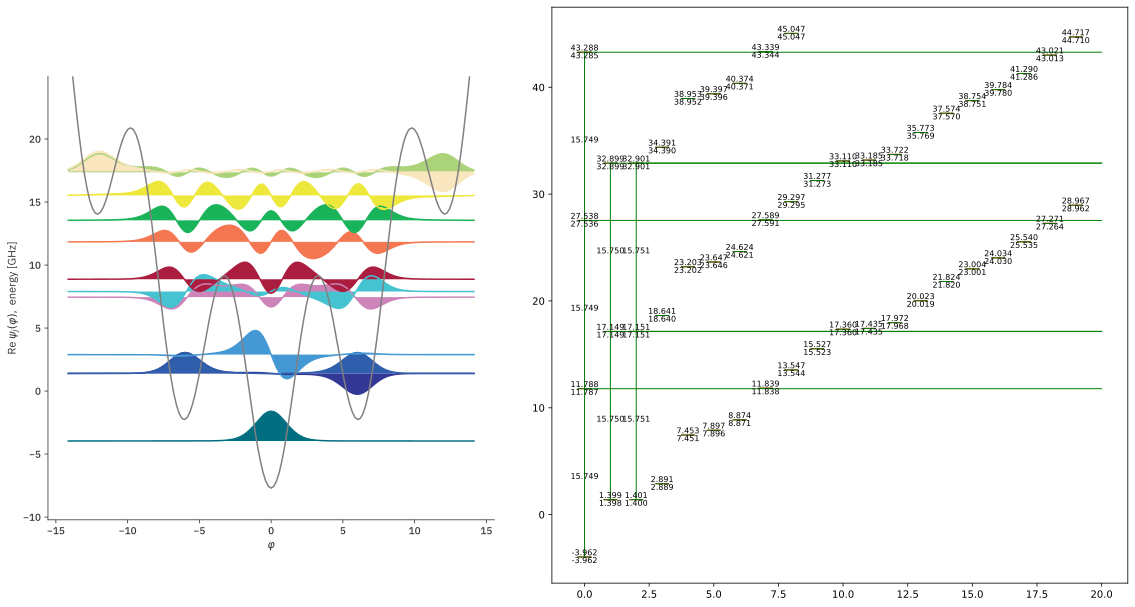

In [160]:

max_ol = 30
max_ql = 20
g = 0.2
system = FluxoniumOscillatorSystem(
    EJ = 7.7,
    EC = 4/4,
    EL = 4/14,
    Er = 15.75,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)